<a href="https://colab.research.google.com/github/TK-Problem/random-experiments/blob/main/001_bayesian_linear_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from datetime import date, timedelta
from IPython.display import clear_output

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="arviz")

## Configuration

- **Target**: `SPY` (S&P 500 ETF) — the variable we are trying to predict.
- **Predictors**: 8 ETFs/indices covering equity factors, commodities, rates, and volatility, plus 7 major tech stocks (MAG 7).
- **Window**: `N_TRAIN` trading days for training, `N_TEST` most recent days held out.
- **Lag**: predictors are shifted by `LAG=1` day so that on day *t*, the model only uses predictor values from day *t−1*.

In [2]:
N_TRAIN = 60   # Trading days used for training
N_TEST = 5    # Most recent days reserved for testing
N_DAYS = N_TRAIN + N_TEST  # Total trading days needed

TARGET = "SPY"
PREDICTORS = [
    # 8 ETFs / indices
    "QQQ",   # Nasdaq 100
    "IWM",   # Russell 2000 (small cap)
    "GLD",   # Gold
    "TLT",   # Long-term Treasuries
    "VIX",   # Volatility index (^VIX in yfinance)
    "XLE",   # Energy sector
    "XLF",   # Financials sector
    "EEM",   # Emerging markets
    # 7 MAG 7 stocks
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "NVDA",  # Nvidia
    "GOOGL", # Alphabet
    "AMZN",  # Amazon
    "META",  # Meta
    "TSLA",  # Tesla
]

# Request ~1.5x calendar days to guarantee N_DAYS trading days after weekends/holidays
END_DATE = date.today().strftime("%Y-%m-%d")
START_DATE = (date.today() - timedelta(days=int(N_DAYS * 2))).strftime("%Y-%m-%d")
LAG = 1   # Days to lag predictors (1 = previous day)
RANDOM_SEED = 42

## Load Data

Download `N_DAYS` worth of adjusted closing prices from Yahoo Finance for all tickers.
`^VIX` is renamed to `VIX` for consistency. Daily log returns `ln(P_t / P_{t-1})` are computed
and the result is trimmed to the `N_DAYS` most recent trading days to keep the window fixed.

In [3]:
print("Downloading price data from Yahoo Finance...")
tickers = [TARGET] + PREDICTORS
# ^VIX needs special handling
yf_tickers = [t if t != "VIX" else "^VIX" for t in tickers]

raw = yf.download(yf_tickers, start=START_DATE, end=END_DATE, auto_adjust=True)["Close"]

# Rename ^VIX back to VIX
raw.columns = [c.replace("^", "") for c in raw.columns]

# Compute daily log returns
returns = np.log(raw / raw.shift(1)).dropna()
print(f"Downloaded {len(returns)} trading days of data.\n")

[*********************100%***********************]  16 of 16 completed

Downloaded 87 trading days of data.



In [4]:
returns.head()

,AAPL,AMZN,EEM,GLD,GOOGL,IWM,META,MSFT,NVDA,QQQ,SPY,TLT,TSLA,XLE,XLF,VIX
Date,,,,,,,,,,,,,,,,
2025-11-06,-0.001371,-0.029035,-0.007466,-0.001201,0.001546,-0.017855,-0.027112,-0.020035,-0.037209,-0.018803,-0.010787,0.008953,-0.035599,0.009676,-0.003619,0.079487
2025-11-07,-0.004831,0.005621,-0.002929,0.006100,-0.021010,0.005229,0.004465,-0.000563,0.000372,-0.003160,0.000984,-0.002119,-0.037449,0.014285,0.007035,-0.021774
2025-11-10,0.004538,0.016193,0.017445,0.026974,0.039623,0.009966,0.016036,0.018309,0.056317,0.021883,0.015484,-0.000223,0.035923,0.009006,0.003593,-0.080742
2025-11-11,0.021371,0.002814,0.001080,0.003930,0.004162,0.000860,-0.007435,0.005282,-0.030037,-0.002667,0.002287,0.004568,-0.012680,0.012976,0.004521,-0.018349
2025-11-12,-0.006488,-0.019867,0.000180,0.015982,-0.015917,-0.002460,-0.029239,0.004824,0.003308,-0.000789,0.000556,0.001777,-0.020731,-0.014083,0.008608,0.013222


## Feature engineering

Shift each predictor return back by `LAG` days so that on day *t* the model only sees
information from day *t−1*. The shifted frame and the target are inner-joined and rows
with any NaN (introduced by the shift) are dropped, leaving an aligned `(n_days, n_features)`
design matrix and a `(n_days,)` target vector.

In [5]:
# Target: SPY return on day t
y_series = returns[TARGET].copy()

# Features: each predictor's return on day t-LAG
X_df = returns[PREDICTORS].shift(LAG)

# Align and drop NaNs
df = pd.concat([y_series.rename("target"), X_df], axis=1).dropna()

y = df["target"].values
X_raw = df[PREDICTORS].values

print(f"Feature matrix shape: {X_raw.shape}")
print(f"Target vector shape:  {y.shape}\n")

Feature matrix shape: (86, 15)
Target vector shape:  (86,)



## Train / Test split

Take the `N_TRAIN + N_TEST` most recent rows and split chronologically — no shuffling to avoid
look-ahead bias. A `StandardScaler` is fitted **only on the training set** and then applied to
the test set, so test statistics are never seen during normalisation.

In [6]:
df_split = df.tail(N_TRAIN + N_TEST)

X_all = df_split[PREDICTORS].values
y_all = df_split["target"].values

X_train_raw, X_test_raw = X_all[:N_TRAIN], X_all[N_TRAIN:]
y_train, y_test = y_all[:N_TRAIN], y_all[N_TRAIN:]
dates_test = df_split.index[N_TRAIN:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Train: {len(y_train)} days ({df_split.index[0].date()} - {df_split.index[N_TRAIN - 1].date()})")
print(f"Test: {len(y_test)} days ({dates_test[0].date()} - {dates_test[-1].date()})")

Train: 60 days (2025-12-09 - 2026-03-06)
Test: 5 days (2026-03-09 - 2026-03-13)


## Single-Beta Bayesian models

For each predictor independently, fit a simple Bayesian linear regression:
`SPY_t = α + β · predictor_{t-1} + ε`. Weakly informative Gaussian priors are placed on `α`
and `β` (centred at 0, reflecting prior belief that daily return predictability is small),
and a `HalfNormal` prior on `σ`. Posterior is sampled via NUTS with 4 chains, 1,000 draws,
and 500 tuning steps.

In [7]:
single_traces = {}

print("Fitting single-beta models...\n")
for i, predictor in enumerate(PREDICTORS):
    x_tr = X_train[:, i]

    with pm.Model():
        alpha = pm.Normal("alpha", mu=0, sigma=0.01)
        beta = pm.Normal("beta",  mu=0, sigma=0.05)
        sigma = pm.HalfNormal("sigma", sigma=0.01)
        mu = alpha + beta * x_tr
        likelihood = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train)

        trace = pm.sample(
            draws=1000,
            tune=500,
            chains=4,
            target_accept=0.9,
            random_seed=RANDOM_SEED,
            progressbar=False,
        )

    single_traces[predictor] = trace
    b_mean = float(trace.posterior["beta"].values.mean())
    b_std  = float(trace.posterior["beta"].values.std())
    rhat   = float(az.summary(trace, var_names=["beta"])["r_hat"].values[0])
    print(f"  {predictor:6s}  beta={b_mean:+.5f} ± {b_std:.5f}  r_hat={rhat:.3f}")

clear_output(wait=True)
print("All single-beta sampling complete.")

All single-beta sampling complete.


## Single-Beta evaluation

Apply each single-predictor posterior to the held-out test set. The posterior predictive mean
is used as the point forecast and compared against actual SPY returns via R², RMSE, and
Pearson correlation. This establishes individual baselines before the joint model is built.

### In-Sample metrics

Evaluate each single-beta posterior on the **training set**. High in-sample R² with poor
out-of-sample R² would indicate overfitting; similar values suggest the model generalises.

In [8]:
print('--- Single-Beta In-Sample Metrics ---\n')
single_train_metrics = []

for i, predictor in enumerate(PREDICTORS):
    tr    = single_traces[predictor]
    x_tr  = X_train[:, i]
    post_a = tr.posterior['alpha'].values.flatten()
    post_b = tr.posterior['beta'].values.flatten()

    mu_pred      = post_a[:, None] + post_b[:, None] * x_tr[None, :]
    y_pred_mean  = mu_pred.mean(axis=0)

    ss_res = np.sum((y_train - y_pred_mean) ** 2)
    ss_tot = np.sum((y_train - y_train.mean()) ** 2)
    r2   = 1 - ss_res / ss_tot
    rmse = np.sqrt(np.mean((y_train - y_pred_mean) ** 2))
    corr = np.corrcoef(y_train, y_pred_mean)[0, 1]

    single_train_metrics.append({'ETF': predictor, 'R²': r2, 'RMSE': rmse, 'Corr': corr})
    print(f'  {predictor:6s}  R²={r2:+.4f}  RMSE={rmse:.4f}  Corr={corr:+.4f}')

single_train_metrics_df = pd.DataFrame(single_train_metrics).set_index('ETF')
print(f"\nBest single predictor by in-sample R²: {single_train_metrics_df['R²'].idxmax()}")

--- Single-Beta In-Sample Metrics ---

  QQQ     R²=+0.0067  RMSE=0.0070  Corr=+0.0820
  IWM     R²=+0.0001  RMSE=0.0071  Corr=+0.0103
  GLD     R²=+0.0049  RMSE=0.0071  Corr=+0.0698
  TLT     R²=+0.0779  RMSE=0.0068  Corr=+0.2791
  VIX     R²=+0.0191  RMSE=0.0070  Corr=+0.1382
  XLE     R²=+0.0020  RMSE=0.0071  Corr=+0.0448
  XLF     R²=+0.0170  RMSE=0.0070  Corr=+0.1306
  EEM     R²=+0.0016  RMSE=0.0071  Corr=+0.0403
  AAPL    R²=+0.0159  RMSE=0.0070  Corr=+0.1262
  MSFT    R²=+0.0207  RMSE=0.0070  Corr=+0.1437
  NVDA    R²=+0.0012  RMSE=0.0071  Corr=+0.0343
  GOOGL   R²=+0.0102  RMSE=0.0070  Corr=+0.1011
  AMZN    R²=+0.0189  RMSE=0.0070  Corr=+0.1374
  META    R²=+0.0066  RMSE=0.0070  Corr=+0.0812
  TSLA    R²=+0.0009  RMSE=0.0071  Corr=+0.0306

Best single predictor by in-sample R²: TLT


## Multi-Variable Bayesian Linear Regression (use best features)

Extend the single-beta approach to a joint model:
`SPY_t = α + β₁·X₁ + … + β_k·X_k + ε`, where k features are selected by in-sample R². Fitting all predictors together lets the model account for inter-predictor correlations and partial out shared variance, which the single-beta models cannot do. Same prior structure as the single-beta models; 4 chains, 2,000 draws, 1,000 tuning steps.

In [9]:
# Select top 5 features by in-sample R²
ranked_df = single_train_metrics_df.copy()
ranked_df = ranked_df.sort_values("R²").tail(5)
BEST_PREDICTORS = ranked_df.index.to_list()
best_idx = [PREDICTORS.index(p) for p in BEST_PREDICTORS]

X_train_multi = X_train[:, best_idx]
X_test_multi = X_test[:, best_idx]

print(f"Selected {len(BEST_PREDICTORS)} features (top by in-sample R²): {BEST_PREDICTORS}")
ranked_df.sort_values("Corr")

Selected 5 features (top by in-sample R²): ['XLF', 'AMZN', 'VIX', 'MSFT', 'TLT']


,R²,RMSE,Corr
ETF,,,
XLF,0.017042,0.007013,0.130645
AMZN,0.018866,0.007006,0.137354
VIX,0.019087,0.007005,0.138171
MSFT,0.020656,0.007000,0.143733
TLT,0.077891,0.006792,0.279147


In [10]:
n_features = X_train_multi.shape[1]

with pm.Model() as model:
    alpha = pm.Normal("alpha", mu=0, sigma=0.01)
    betas = pm.Normal("betas", mu=0, sigma=0.05, shape=n_features)
    sigma = pm.HalfNormal("sigma", sigma=0.01)
    mu = alpha + pm.math.dot(X_train_multi, betas)
    likelihood = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train)

    print("Sampling posterior (this may take a minute)...")
    trace = pm.sample(
        draws=2000, tune=1000, chains=4,
        target_accept=0.9, random_seed=RANDOM_SEED,
        progressbar=True,
    )

clear_output(wait=True)
print("\nSampling complete!")
summary = az.summary(trace, var_names=["alpha", "betas", "sigma"], round_to=6)
summary.index = ["alpha"] + [f"beta_{p}" for p in BEST_PREDICTORS] + ["sigma"]
print("\n--- Posterior Summary ---")
print(summary.to_string(index=False))

# Extract posterior samples for reuse across subsequent cells
post_alpha = trace.posterior["alpha"].values.flatten()
post_betas = trace.posterior["betas"].values.reshape(-1, n_features)
post_sigma = trace.posterior["sigma"].values.flatten()


Sampling complete!

--- Posterior Summary ---
     mean       sd    hdi_3%  hdi_97%  mcse_mean  mcse_sd     ess_bulk    ess_tail    r_hat
-0.000221 0.000927 -0.002046 0.001487   0.000008 0.000011 11943.754084 5389.473250 1.001123
-0.000127 0.001162 -0.002411 0.001974   0.000013 0.000013  8380.376550 5576.814106 1.000047
-0.000372 0.001069 -0.002352 0.001646   0.000011 0.000012 10023.943776 6343.893688 1.000247
 0.000756 0.001259 -0.001811 0.002923   0.000015 0.000013  7540.906599 6061.425478 1.000130
-0.000426 0.000974 -0.002268 0.001371   0.000009 0.000012 11478.444120 6380.669646 1.000258
 0.001927 0.000966  0.000124 0.003762   0.000009 0.000011 10634.458271 5867.847758 1.000036
 0.007158 0.000708  0.005894 0.008517   0.000007 0.000009  9896.843273 6128.795497 1.000166


## In-Sample diagnostics

**Trace plots**: verify that each chain mixes well (caterpillar-like traces) and that the marginal distributions across chains agree. R-hat < 1.01 for all parameters indicates good convergence.

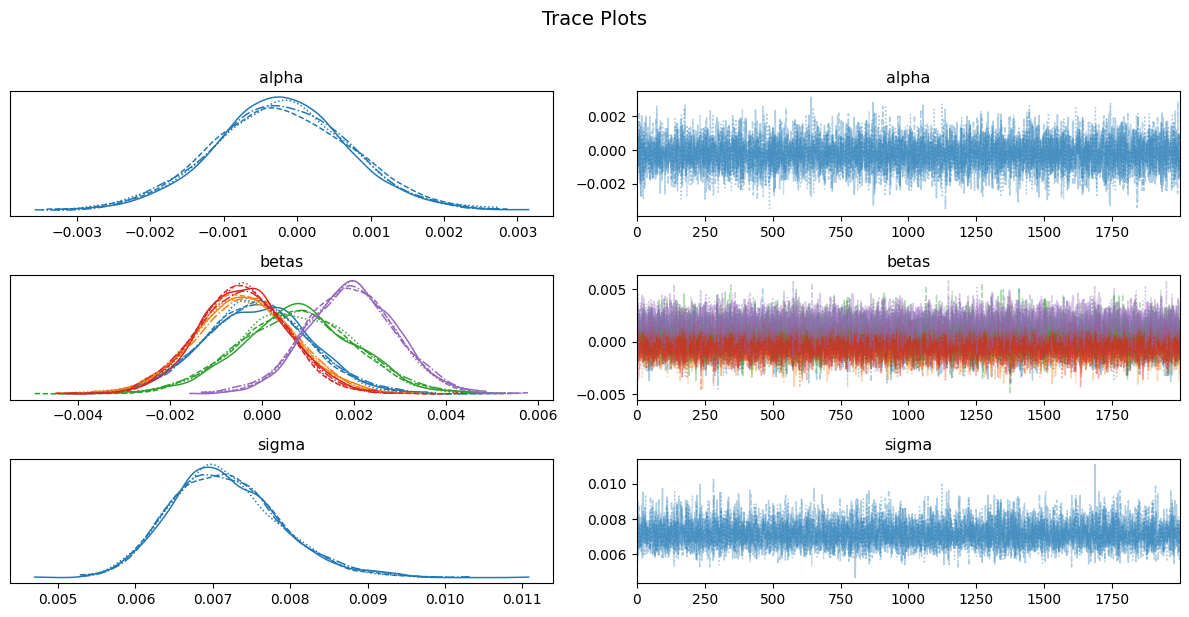

In [11]:
az.plot_trace(trace, var_names=["alpha", "betas", "sigma"], compact=True)
plt.suptitle("Trace Plots", fontsize=14, y=1.02)
plt.tight_layout()

**Forest plot**: shows posterior 94% HDI for each `β` with R-hat values — R-hat < 1.01 indicates good convergence. A red dashed line at 0 highlights coefficients whose HDI excludes zero (credibly non-zero effects).

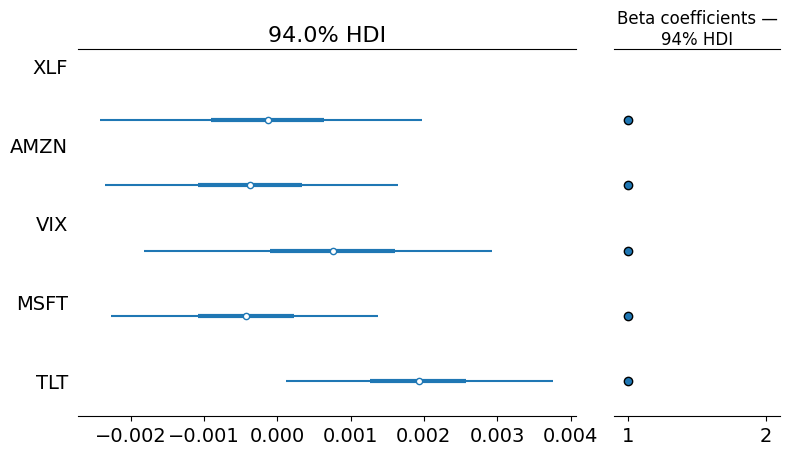

In [12]:
az.plot_forest(trace, var_names=["betas"],
               combined=True, hdi_prob=0.94, r_hat=True)
plt.axvline(0, color="red", linestyle="--", alpha=0.6)
plt.yticks(ticks=range(n_features), labels=BEST_PREDICTORS[::-1])
plt.title("Beta coefficients — 94% HDI")
plt.tight_layout()

plt.show()

## In-Sample predictions

Apply the posterior to the **training set** to check how well the model fits the data it
was trained on. The posterior predictive mean and 94% HDI are derived from the same
posterior samples used for the forest plot above. Large residuals or a systematic pattern
here would suggest model misspecification.

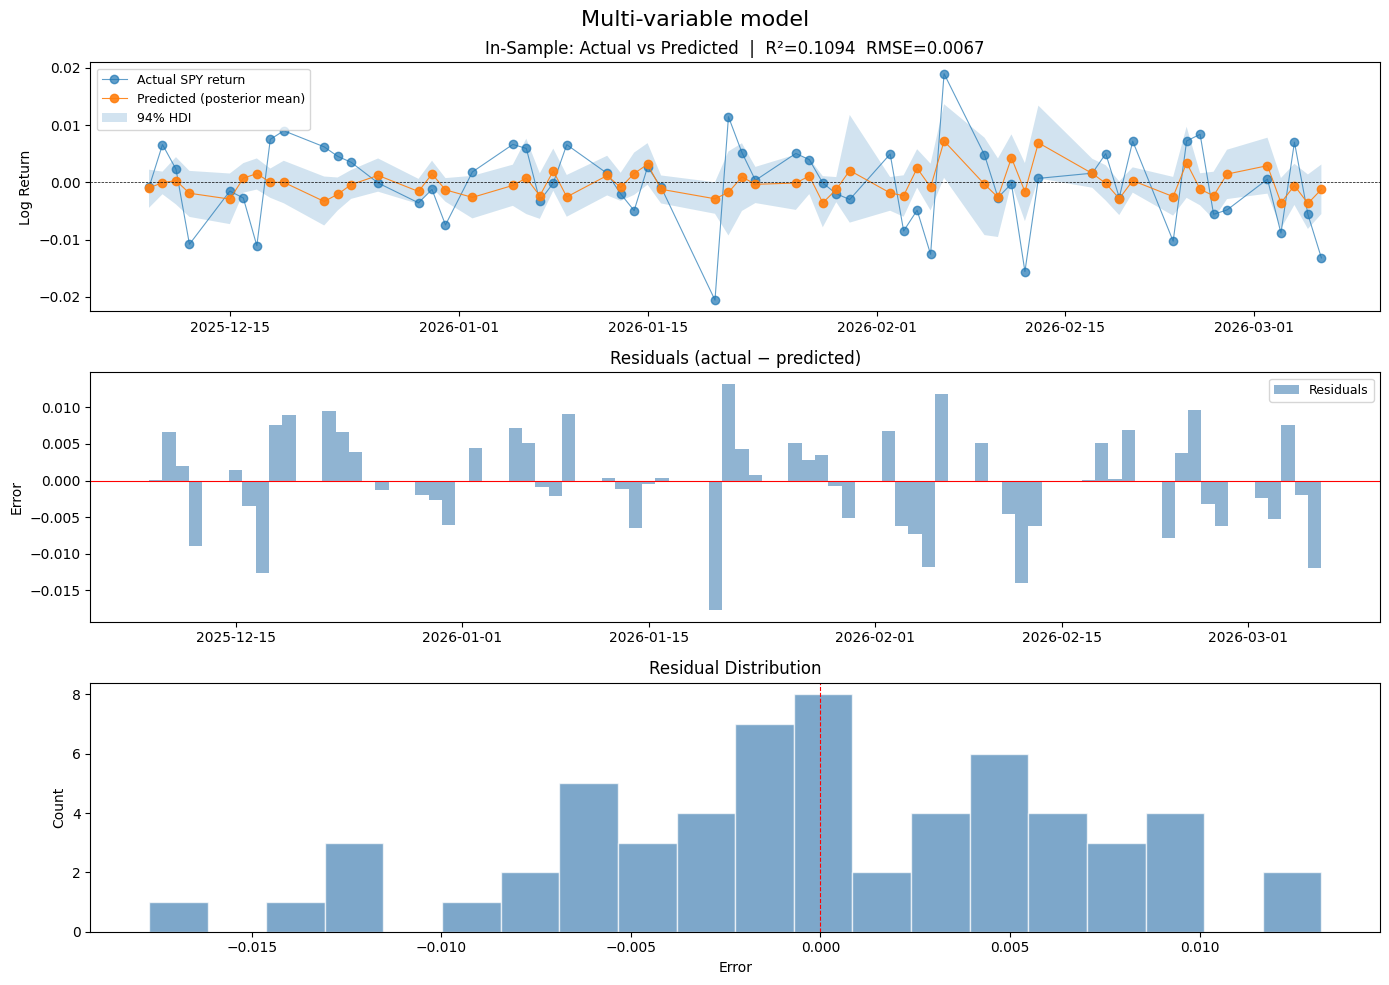

In [13]:
# Posterior predictive mean on training set
mu_train = post_alpha[:, None] + post_betas @ X_train_multi.T  # (samples, n_train)
y_train_pred_mean = mu_train.mean(axis=0)
y_train_pred_hdi  = az.hdi(mu_train[None, :, :], hdi_prob=0.94)

ss_res_tr = np.sum((y_train - y_train_pred_mean) ** 2)
ss_tot_tr = np.sum((y_train - y_train.mean()) ** 2)
r2_train  = 1 - ss_res_tr / ss_tot_tr
rmse_train = np.sqrt(np.mean((y_train - y_train_pred_mean) ** 2))

dates_train = df_split.index[:N_TRAIN]
residuals_train = y_train - y_train_pred_mean

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# --- actual vs predicted ---
axes[0].plot(dates_train, y_train, "o-", label='Actual SPY return', alpha=0.7, linewidth=0.8)
axes[0].plot(dates_train, y_train_pred_mean, "o-", label='Predicted (posterior mean)', alpha=0.9, linewidth=0.8)
axes[0].fill_between(dates_train,
                     y_train_pred_hdi[:, 0], y_train_pred_hdi[:, 1],
                     alpha=0.2, label='94% HDI')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_title(f'In-Sample: Actual vs Predicted  |  R²={r2_train:.4f}  RMSE={rmse_train:.4f}')
axes[0].set_ylabel('Log Return')
axes[0].legend(fontsize=9)

# --- residuals ---
axes[1].bar(dates_train, residuals_train, width=1, alpha=0.6, color='steelblue', label='Residuals')
axes[1].axhline(0, color='red', linewidth=0.8)
axes[1].set_title('Residuals (actual − predicted)')
axes[1].set_ylabel('Error')
axes[1].legend(fontsize=9)

# --- residual distribution ---
axes[2].hist(residuals_train, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
axes[2].axvline(0, color='red', linewidth=0.8, linestyle='--')
axes[2].set_title('Residual Distribution')
axes[2].set_xlabel('Error')
axes[2].set_ylabel('Count')

fig.suptitle("Multi-variable model", fontsize=16)
fig.tight_layout()

plt.show()

## In-Sample metrics comparison

Compare all single-beta models against the multi-variable model on the **training set**. All metrics here are in-sample, so this is a fair apples-to-apples comparison of how much each model captures of the training data variance.

In [14]:
# --- In-sample metrics for multi-variable model ---
mu_train_multi = post_alpha[:, None] + post_betas @ X_train_multi.T
y_train_multi_mean = mu_train_multi.mean(axis=0)

ss_res_tr = np.sum((y_train - y_train_multi_mean) ** 2)
ss_tot_tr = np.sum((y_train - y_train.mean()) ** 2)
r2_train = 1 - ss_res_tr / ss_tot_tr
rmse_train = np.sqrt(np.mean((y_train - y_train_multi_mean) ** 2))
corr_train = np.corrcoef(y_train, y_train_multi_mean)[0, 1]

print("--- In-Sample Metrics Comparison ---\n")
print(f"{'Model':<24}  {'R²':>8}  {'RMSE':>8}  {'Pearson':>8}")
print('-'*55)
for _, row in single_train_metrics_df.iterrows():
    print(f"  {row.name:<24}  {row['R²']:>+8.4f}  {row['RMSE']:>8.4f}  {row['Corr']:>+8.4f}")
print('-'*55)
print(f"  {'Multi-variable':<24}  {r2_train:>+8.4f}  {rmse_train:>8.4f}  {corr_train:>+8.4f}\n")

--- In-Sample Metrics Comparison ---

Model                           R²      RMSE   Pearson
-------------------------------------------------------
  QQQ                        +0.0067    0.0070   +0.0820
  IWM                        +0.0001    0.0071   +0.0103
  GLD                        +0.0049    0.0071   +0.0698
  TLT                        +0.0779    0.0068   +0.2791
  VIX                        +0.0191    0.0070   +0.1382
  XLE                        +0.0020    0.0071   +0.0448
  XLF                        +0.0170    0.0070   +0.1306
  EEM                        +0.0016    0.0071   +0.0403
  AAPL                       +0.0159    0.0070   +0.1262
  MSFT                       +0.0207    0.0070   +0.1437
  NVDA                       +0.0012    0.0071   +0.0343
  GOOGL                      +0.0102    0.0070   +0.1011
  AMZN                       +0.0189    0.0070   +0.1374
  META                       +0.0066    0.0070   +0.0812
  TSLA                       +0.0009    0.0071   +0.0

## Out-of-Sample (OOS) prediction

Evaluate the multi-variable model on the **held-out test set**. The posterior predictive mean and 94% HDI are derived by applying each posterior sample `(α⁽ˢ⁾, β⁽ˢ⁾)` to `X_test`. Note that the test set contains only `N_TEST=5` observations, so the R² should be interpreted with caution.

In [15]:
# --- Out-of-sample metrics for multi-variable model ---
mu_pred = post_alpha[:, None] + post_betas @ X_test_multi.T
y_pred_mean = mu_pred.mean(axis=0)
y_pred_hdi = az.hdi(mu_pred[None, :, :], hdi_prob=0.94)

ss_res = np.sum((y_test - y_pred_mean) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2_oos = 1 - ss_res / ss_tot
rmse_oos = np.sqrt(np.mean((y_test - y_pred_mean) ** 2))
corr_oos = np.corrcoef(y_test, y_pred_mean)[0, 1]

print("--- Out-of-Sample Metrics (Multi-variable) ---\n")
print(f"  R²      = {r2_oos:>+.4f}")
print(f"  RMSE    = {rmse_oos:>.4f}")
print(f"  Pearson = {corr_oos:>+.4f}\n")

--- Out-of-Sample Metrics (Multi-variable) ---

  R²      = +0.2792
  RMSE    = 0.0066
  Pearson = +0.6210



## Visualize OOS predictions

Two-panel chart for the multi-variable model on the test set:
- **Top**: actual vs. posterior-mean predicted SPY log returns with a 94% HDI band.
- **Bottom**: residuals `(actual − predicted)` as a bar chart to reveal any systematic bias.

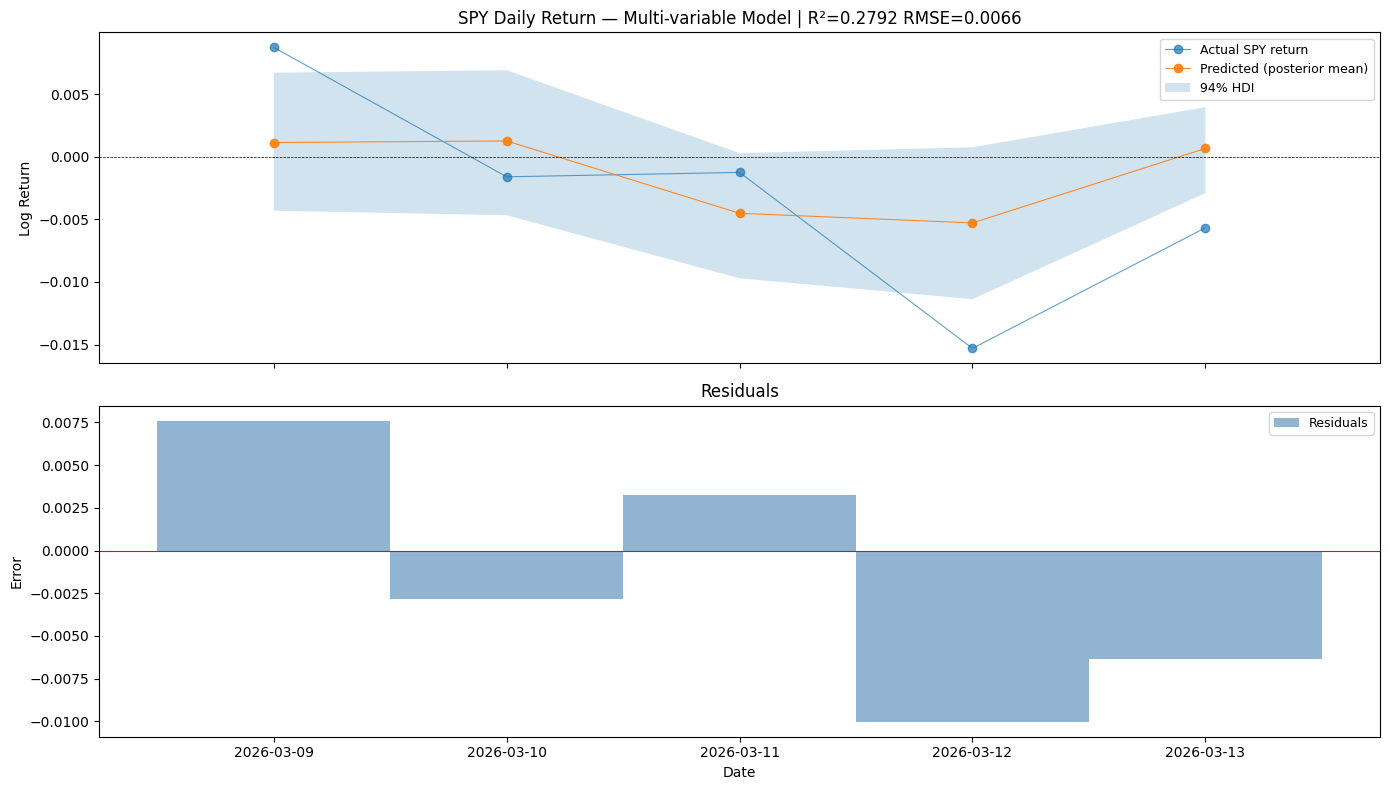

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(dates_test, y_test, "o-", label="Actual SPY return", alpha=0.7, linewidth=0.8)
axes[0].plot(dates_test, y_pred_mean, "o-", label="Predicted (posterior mean)",  alpha=0.9, linewidth=0.8)
axes[0].fill_between(dates_test,
                     y_pred_hdi[:, 0], y_pred_hdi[:, 1],
                     alpha=0.2, label="94% HDI")
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_title(f"SPY Daily Return — Multi-variable Model | R²={r2_oos:.4f} RMSE={rmse_oos:.4f}")
axes[0].legend(fontsize=9)
axes[0].set_ylabel("Log Return")

residuals = y_test - y_pred_mean
axes[1].bar(dates_test, residuals, width=1, alpha=0.6, color="steelblue", label="Residuals")
axes[1].axhline(0, color="red", linewidth=0.8)
axes[1].set_title("Residuals")
axes[1].set_ylabel("Error")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

## Coefficient importance

Rank predictors by their Bayesian signal-to-noise ratio `|β_mean| / β_std` — a higher value
means the posterior is more decisively non-zero relative to its own uncertainty. This is
analogous to a *t*-statistic but operates entirely within the posterior distribution.
The horizontal bar chart shows posterior mean ± 1 std; red = positive effect, blue = negative.

In [17]:
beta_means = post_betas.mean(axis=0)
beta_stds = post_betas.std(axis=0)

coef_df = pd.DataFrame({
    "ETF": BEST_PREDICTORS,
    "beta_mean": beta_means,
    "beta_std": beta_stds,
    "signal": np.abs(beta_means) / beta_stds,
}).sort_values("signal", ascending=False)

print("--- Coefficient Summary (sorted by |mean/std|) ---")
print(coef_df.to_string(index=False))

--- Coefficient Summary (sorted by |mean/std|) ---
 ETF  beta_mean  beta_std   signal
 TLT   0.001927  0.000965 1.995945
 VIX   0.000756  0.001259 0.600656
MSFT  -0.000426  0.000974 0.437076
AMZN  -0.000372  0.001069 0.347575
 XLF  -0.000127  0.001162 0.109287


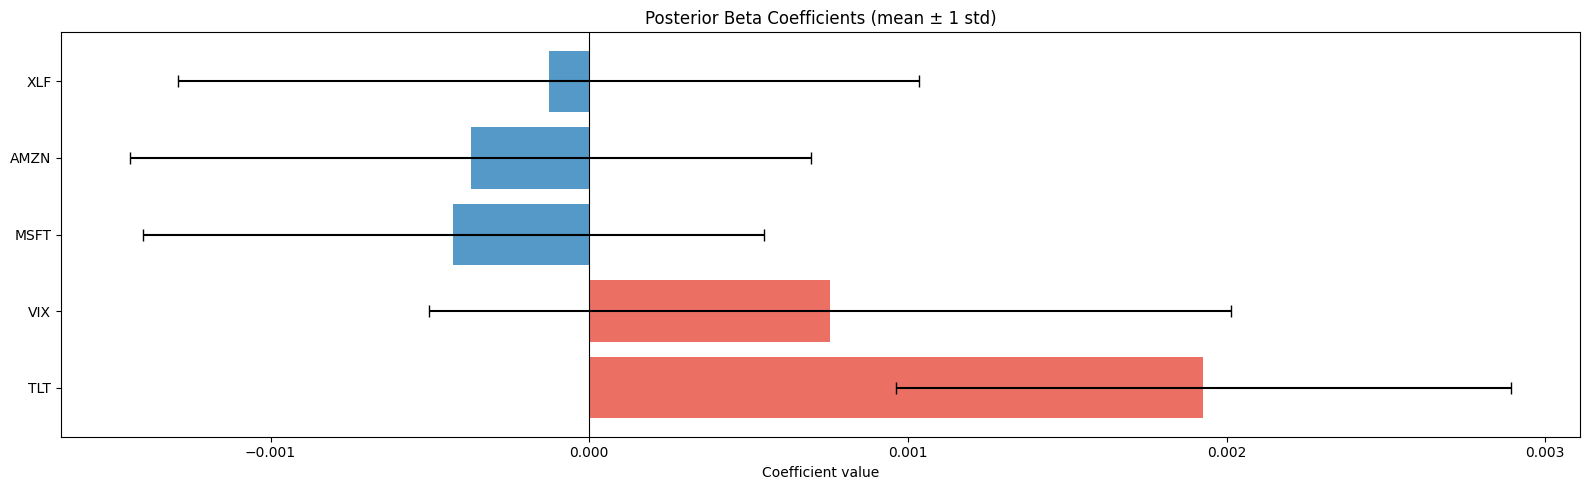

In [18]:
fig, ax = plt.subplots(figsize=(16, 5))
colors = ["#e74c3c" if v > 0 else "#2980b9" for v in coef_df["beta_mean"]]
ax.barh(coef_df["ETF"], coef_df["beta_mean"], xerr=coef_df["beta_std"],
        color=colors, capsize=4, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Posterior Beta Coefficients (mean ± 1 std)")
ax.set_xlabel("Coefficient value")
fig.tight_layout()
plt.show()